Loading ET data...
ET data columns: ['Date', 'Noah_MP_ET', 'CLM_ET', 'CLASS_ET', 'OBS_ET', 'PR']
ET data shape: (1415, 6)
Processing dates...
Date range in data:
  Start: 2014-01-03 00:00:00
  End: 2017-11-17 00:00:00
  Total days: 1415
Extracting ET data...
Successfully extracted all ET data
Data summary:
        Noah_MP_ET       CLM_ET     CLASS_ET       OBS_ET
count  1415.000000  1414.000000  1411.000000  1399.000000
mean      0.887536     0.864070     0.837725     0.857416
std       1.021125     0.922696     0.944825     1.005153
min       0.002982     0.015053     0.000622    -0.099547
25%       0.049898     0.132386     0.111208     0.082735
50%       0.425577     0.458520     0.462154     0.279260
75%       1.532722     1.368780     1.269052     1.579233
max       4.934777     4.829159     5.551515     4.403061

1. Creating ET seasonal distribution plots...


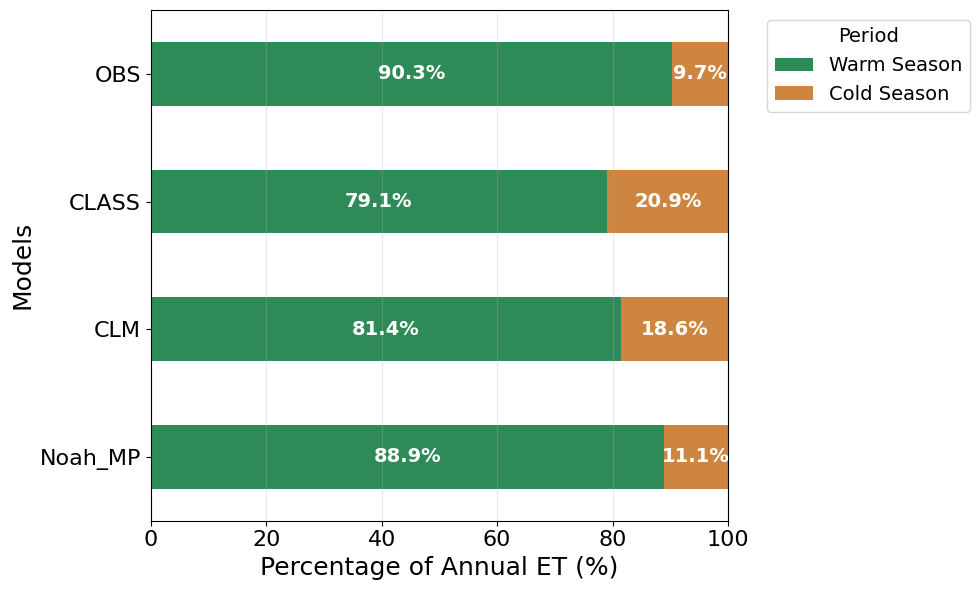


SEASONAL DISTRIBUTION SUMMARY

ET Distribution - Growing Season vs Non-Growing Season:
         Warm Season  Cold Season  Total_ET
Model                                      
Noah_MP         88.9         11.1    1255.9
CLM             81.4         18.6    1221.8
CLASS           79.1         20.9    1182.0
OBS             90.3          9.7    1199.5

Files saved:
- ET_seasonal_distribution.png
- ET_growing_season_distribution.csv

Analysis complete!


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates
import seaborn as sns

def is_growingseason(date):
    """Define growing season as May through September"""
    return date.month in [5, 6, 7, 8, 9]

# Load data
BASE_PATH1 = Path("/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_sens_sim/Vegfraction_sens/")
filename1 = "ET_data.csv"
fullpath1 = BASE_PATH1 / filename1

print("Loading ET data...")
df_ET = pd.read_csv(fullpath1, low_memory=False)
print("ET data columns:", df_ET.columns.tolist())
print("ET data shape:", df_ET.shape)

# Fix date handling
print("Processing dates...")
df_ET['Date'] = pd.to_datetime(df_ET['Date'])
df_ET = df_ET.set_index('Date')

print("Date range in data:")
print(f"  Start: {df_ET.index.min()}")
print(f"  End: {df_ET.index.max()}")
print(f"  Total days: {len(df_ET)}")

# Extract ET data and handle potential missing values
print("Extracting ET data...")
try:
    # Create clean data DataFrame with proper column names
    data = pd.DataFrame({
        "Noah_MP_ET": df_ET['Noah_MP_ET'].astype(float),
        "CLM_ET": df_ET['CLM_ET'].astype(float),
        "CLASS_ET": df_ET['CLASS_ET'].astype(float),
        "OBS_ET": df_ET['OBS_ET'].astype(float)
    }, index=df_ET.index)
    
    print("Successfully extracted all ET data")
    print("Data summary:")
    print(data.describe())
    
except Exception as e:
    print(f"Error extracting ET data: {e}")
    print("Available columns:", df_ET.columns.tolist())

def create_et_seasonal_stacked_bars(data):
    """
    Create horizontal stacked bar charts for seasonal ET analysis
    """
    
    
    def is_growing_season_period(month):
        return 'Warm Season' if month in [5, 6, 7, 8, 9] else 'Cold Season'
    
    # Prepare data with season information
    data_with_seasons = data.copy()
    data_with_seasons['Month'] = data_with_seasons.index.month
    data_with_seasons['Period'] = data_with_seasons['Month'].map(is_growing_season_period)
    
    models = ['Noah_MP_ET', 'CLM_ET', 'CLASS_ET', 'OBS_ET']
    
    # Create figure with subplots
    fig, ax1  = plt.subplots(1, 1, figsize=(10, 6))
    
    # Color schemes
    period_colors = {'Warm Season': '#2E8B57', 'Cold Season': '#CD853F'}
    season_colors = {'Winter': '#4682B4', 'Spring': '#32CD32', 'Summer': '#FF6347', 'Fall': '#DAA520'}
    
    # === LEFT PLOT: Growing Season vs Non-Growing Season ET VALUES ===
    period_data = []
    
    for model in models:
        model_data = data_with_seasons.dropna(subset=[model])
        
        if len(model_data) > 0:
            # Calculate total ET by period
            period_values = model_data.groupby('Period')[model].sum()
            
            # Calculate percentages
            total_value = period_values.sum()
            if total_value > 0:
                period_percentages = (period_values / total_value * 100).reindex(['Warm Season', 'Cold Season'], fill_value=0)
            else:
                period_percentages = pd.Series([50, 50], index=['Warm Season', 'Cold Season'])
            
            period_data.append({
                'Model': model.replace('_ET', ''),
                'Warm Season': period_percentages['Warm Season'],
                'Cold Season': period_percentages['Cold Season'],
                'Total_ET': total_value
            })
    
    period_df = pd.DataFrame(period_data).set_index('Model')
    
    # Create horizontal stacked bar for periods
    plot_data = period_df[['Warm Season', 'Cold Season']]
    plot_data.plot(kind='barh', stacked=True, ax=ax1, color=[period_colors[col] for col in plot_data.columns])
   # ax1.set_title('ET Distribution by Growing Season\n(Percentage of Annual Total)', fontsize=14, pad=20)
    ax1.set_xlabel('Percentage of Annual ET (%)', fontsize=18)
    ax1.set_ylabel('Models', fontsize=18)
    ax1.legend(title='Period', bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=14,title_fontsize=14)
    ax1.grid(axis='x', alpha=0.3)
    ax1.set_xlim(0, 100)
    ax1.tick_params(axis='x', labelsize=16)  # X-axis tick labels (0, 20, 40, 60, 80, 100)
    ax1.tick_params(axis='y', labelsize=16)
    
    # Add percentage labels
    for i, (idx, row) in enumerate(plot_data.iterrows()):
        cumsum = 0
        for j, (col, val) in enumerate(row.items()):
            if val > 5:  # Only show label if segment is large enough
                ax1.text(cumsum + val/2, i, f'{val:.1f}%', 
                        ha='center', va='center', fontweight='bold', color='white', fontsize=14)
            cumsum += val
    
    #plt.suptitle('Annual ET Distribution Across Seasons', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.savefig('ET_warm_season_distribution.png', dpi=300, bbox_inches='tight')
    return fig, period_df



# 1. ET Value Distribution
print("\n1. Creating ET seasonal distribution plots...")
fig1, period_et = create_et_seasonal_stacked_bars(data)
plt.savefig('ET_seasonal_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


# Print summary statistics
print("\n" + "="*60)
print("SEASONAL DISTRIBUTION SUMMARY")
print("="*60)

print("\nET Distribution - Growing Season vs Non-Growing Season:")
print(period_et.round(1))


# Export summary data
period_et.to_csv('ET_growing_season_distribution.csv')


print("\nFiles saved:")
print("- ET_seasonal_distribution.png")

print("- ET_growing_season_distribution.csv")

print("\nAnalysis complete!")